In [3]:
import os

try:
    from lerobot.datasets.lerobot_dataset import LeRobotDataset
    _LEROBOT_VERSION = '2.1'
except:
    from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
    _LEROBOT_VERSION = '2.0'

data_root = '../data/'
repo_id = 'Koorye/pika'

data_root = os.path.join(data_root, repo_id)
if _LEROBOT_VERSION == '2.1':
    dataset = LeRobotDataset(repo_id=repo_id, root=data_root)
else:
    dataset = LeRobotDataset(repo_id=repo_id, root=data_root, local_files_only=True)

iterator = iter(dataset)

Generating train split: 27 examples [00:00, 2994.43 examples/s]


dict_keys(['third_base_rgb', 'left_wrist_base_rgb', 'left_wrist_fisheye_rgb', 'right_wrist_base_rgb', 'right_wrist_fisheye_rgb', 'states', 'actions', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])
do something
tensor([0.3393, 0.5030, 0.7634, 0.1325, 0.5868, 0.4064, 0.6110, 0.1074, 0.7010,
        0.3360, 0.7591, 0.6519, 0.4501, 0.3370])
torch.Size([3, 480, 640])


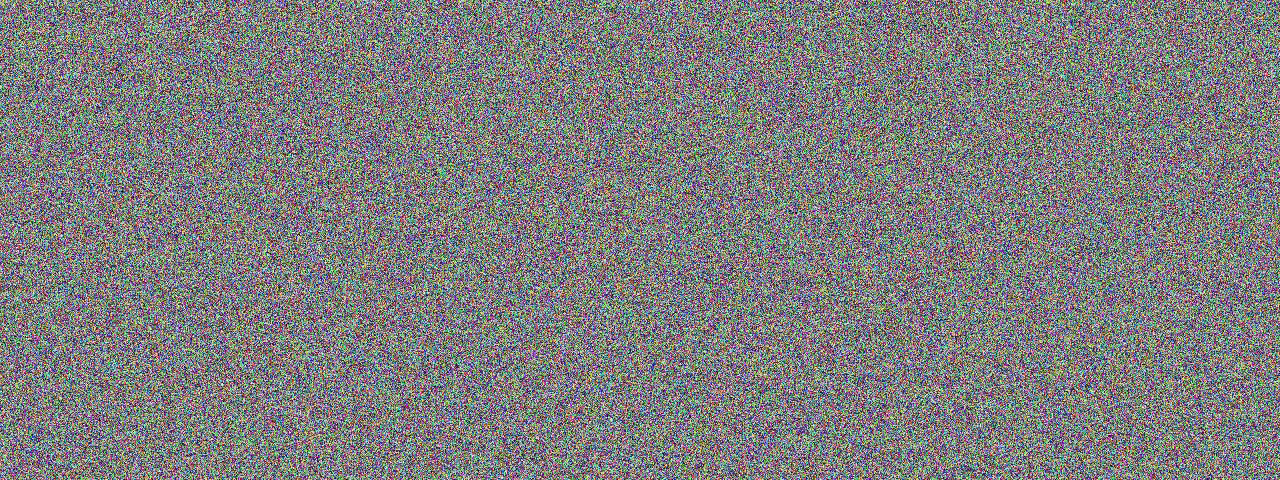

In [5]:
import cv2
import numpy as np
from PIL import Image


def get_next_sample(iterator, k):
    sample = next(iterator)
    for _ in range(k - 1):
        sample = next(iterator)
    return sample

sample = get_next_sample(iterator, 1)
print(sample.keys())
print(sample['task'])
print(sample['actions'])
print(sample['left_wrist_fisheye_rgb'].shape)
Image.fromarray(cv2.hconcat([
    np.uint8(sample['left_wrist_fisheye_rgb'].permute(1, 2, 0).numpy() * 255), 
    np.uint8(sample['right_wrist_fisheye_rgb'].permute(1, 2, 0).numpy() * 255),
]))

In [ ]:
iterator = iter(dataset)
samples = []
for _ in range(10):
    sample = next(iterator)
    samples.append(sample)

left_states = [sample['states'][:3] for sample in samples]
right_states = [sample['states'][7:10] for sample in samples]

left_positions = [sample['actions'][:3] for sample in samples]
right_positions = [sample['actions'][7:10] for sample in samples]

import matplotlib.pyplot as plt
import numpy as np

# plot 3d
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    [pos[0] for pos in left_positions],
    [pos[1] for pos in left_positions],
    [pos[2] for pos in left_positions],
    c='r', marker='o', label='Left Wrist'
)
ax.scatter(
    [pos[0] for pos in right_positions],
    [pos[1] for pos in right_positions],
    [pos[2] for pos in right_positions],
    c='b', marker='^', label='Right Wrist'
)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Wrist Positions')                                                
ax.legend()
plt.show()

StopIteration: 

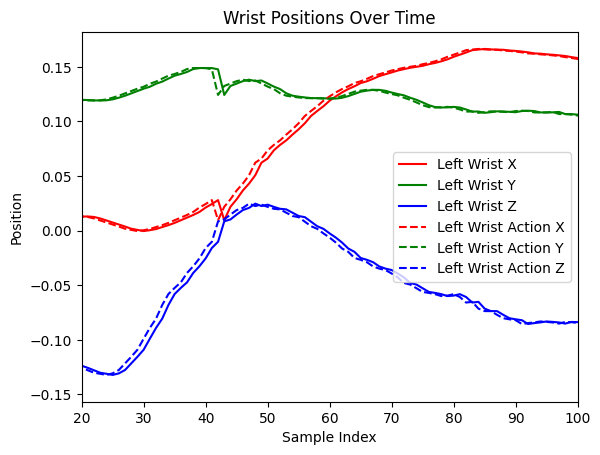

In [ ]:
plt.plot(np.arange(len(left_states)), [state[0] for state in left_states], label='Left Wrist X', c='r')
plt.plot(np.arange(len(left_states)), [state[1] for state in left_states], label='Left Wrist Y', c='g')
plt.plot(np.arange(len(left_states)), [state[2] for state in left_states], label='Left Wrist Z', c='b')
plt.plot(np.arange(len(left_positions)), [action[0] for action in left_positions], label='Left Wrist Action X', c='r', linestyle='--')
plt.plot(np.arange(len(left_positions)), [action[1] for action in left_positions], label='Left Wrist Action Y', c='g', linestyle='--')
plt.plot(np.arange(len(left_positions)), [action[2] for action in left_positions], label='Left Wrist Action Z', c='b', linestyle='--')
plt.xlabel('Sample Index')
plt.ylabel('Position')
plt.title('Wrist Positions Over Time')
plt.legend()
plt.show()